# Starting with the simpliest case
##### author: M.Z. 
##### date: June 30th, 2026

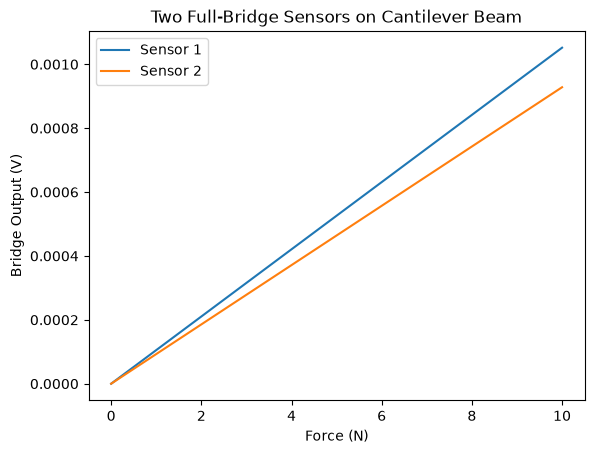

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Beam parameters
# ==============================
L = 0.02          # beam length (m)
E = 200e9        # Young's modulus (Pa) of SS
b = 0.008         # width (m)
t = 0.002        # thickness (m)

I = b * t**3 / 12   # moment of inertia of beam shape, actual design differs.
c = t / 2           # distance from neutral axis

# ==============================
# Sensor configuration
# ==============================
x1 = 0.003   # sensor 1 position (m), arbitrarily chosen to be closer to the fixed end, but can be adjusted as the current prototype is likely not the final design
x2 = 0.005   # sensor 2 position (m)

# Gauge parameters
GF = 2.0       # gauge factor
Vex = 3.3     # bridge excitation voltage (V)

# ==============================
# Full bridge model
# ==============================
def full_bridge_output(strain, GF, Vex):
    return Vex * GF * strain    # estimation, not directly modeling resistance changes in the bridge, but a simplified linear approximation

# ==============================
# Sweep force
# ==============================
forces = np.linspace(0, 10, 50)

V1s = []
V2s = []

for F in forces:
    # Strain at sensor positions (cantilever formula), but this is a tip-loaded (x = L) case
    strain1 = (F * (L - x1)) * c / (E * I)
    strain2 = (F * (L - x2)) * c / (E * I)

    # Full bridge outputs
    V1 = full_bridge_output(strain1, GF, Vex)
    V2 = full_bridge_output(strain2, GF, Vex)

    V1s.append(V1)
    V2s.append(V2)

# ==============================
# Plot results
# ==============================
plt.plot(forces, V1s, label="Sensor 1")
plt.plot(forces, V2s, label="Sensor 2")
plt.xlabel("Force (N)")
plt.ylabel("Bridge Output (V)")
plt.title("Two Full-Bridge Sensors on Cantilever Beam")
plt.legend()
plt.show()

## now with a bit noise

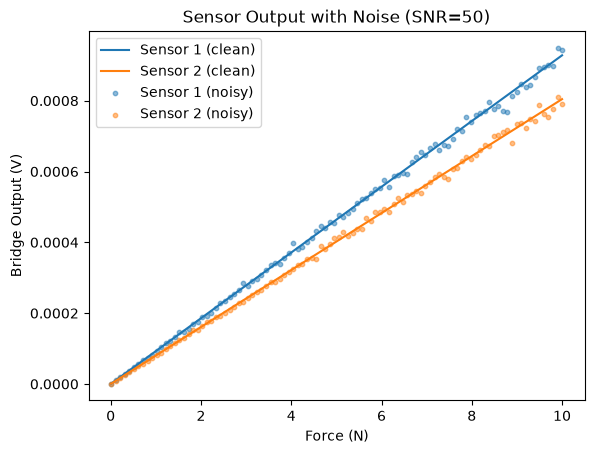

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Previously configured (unchanged)
# ==============================
# L, E, b, t, I, c, x1, x2, GF, and Vex were already set up in the earlier setup cell.
# The bridge output helper is also already defined there.

# ==============================
# Force + contact location
# ==============================
forces = np.linspace(0.01, 10, 100)  # avoid 0 (for noise scaling)
x_force = 0.018  # where force is applied (near tip)

# ==============================
# Noise settings
# ==============================
SNR = 50  # signal-to-noise ratio, boarderline case as stated by SWE

V1s = []
V2s = []
V1s_noisy = []
V2s_noisy = []

for F in forces:
    # strain based on arbitrary force location
    strain1 = (F * (x_force - x1)) * c / (E * I)
    strain2 = (F * (x_force - x2)) * c / (E * I)

    V1 = full_bridge_output(strain1, GF, Vex)
    V2 = full_bridge_output(strain2, GF, Vex)

    # Add noise
    noise1 = V1 / SNR * np.random.randn()
    noise2 = V2 / SNR * np.random.randn()

    V1s.append(V1)
    V2s.append(V2)

    V1s_noisy.append(V1 + noise1)
    V2s_noisy.append(V2 + noise2)

# ==============================
# Plot
# ==============================
plt.plot(forces, V1s, label="Sensor 1 (clean)")
plt.plot(forces, V2s, label="Sensor 2 (clean)")

plt.scatter(forces, V1s_noisy, s=10, alpha=0.5, label="Sensor 1 (noisy)")
plt.scatter(forces, V2s_noisy, s=10, alpha=0.5, label="Sensor 2 (noisy)")

plt.xlabel("Force (N)")
plt.ylabel("Bridge Output (V)")
plt.title("Sensor Output with Noise (SNR=50)")
plt.legend()
plt.show()

## under this simpliest model, how different is the estimated force as compared with the input force

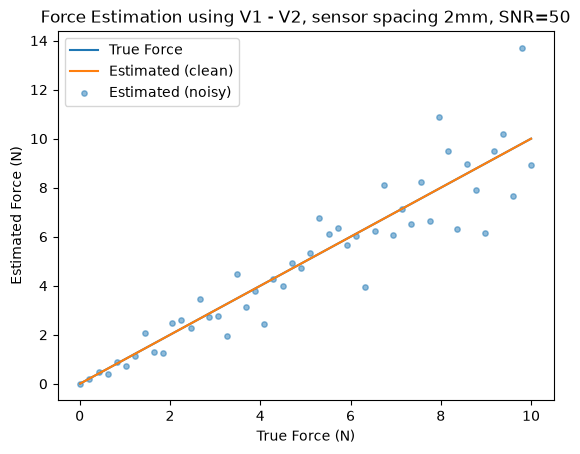

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Previously configured (unchanged)
# ==============================
# L, E, b, t, I, c, x1, x2, GF, Vex, and full_bridge_output were already set up earlier.
# Only the force sweep and reconstruction logic are being evaluated here.

# ==============================
# Force + location
# ==============================
forces = np.linspace(0.01, 10, 50)
x_force = 0.018

# ==============================
# Noise settings
# ==============================
SNR = 50

V1_clean = []
V2_clean = []
V1_noisy = []
V2_noisy = []

for F in forces:
    strain1 = (F * (x_force - x1)) * c / (E * I)
    strain2 = (F * (x_force - x2)) * c / (E * I)

    V1 = full_bridge_output(strain1, GF, Vex)
    V2 = full_bridge_output(strain2, GF, Vex)

    noise1 = V1 / SNR * np.random.randn()
    noise2 = V2 / SNR * np.random.randn()

    V1_clean.append(V1)
    V2_clean.append(V2)

    V1_noisy.append(V1 + noise1)
    V2_noisy.append(V2 + noise2)

# ==============================
# Force reconstruction: V1 - V2
# ==============================

# calibration factor (derived from model)
K = (Vex * GF * c / (E * I)) * (x2 - x1)

F_est_clean = []
F_est_noisy = []

for i in range(len(forces)):
    dV_clean = V1_clean[i] - V2_clean[i]
    dV_noisy = V1_noisy[i] - V2_noisy[i]

    F_est_clean.append(dV_clean / K)
    F_est_noisy.append(dV_noisy / K)

# ==============================
# Plot
# ==============================

plt.plot(forces, forces, label="True Force")
plt.plot(forces, F_est_clean, label="Estimated (clean)")
plt.scatter(forces, F_est_noisy, s=15, alpha=0.5, label="Estimated (noisy)")

plt.xlabel("True Force (N)")
plt.ylabel("Estimated Force (N)")
plt.title("Force Estimation using V1 - V2, sensor spacing 2mm, SNR=50")
plt.legend()
plt.show()

### Increasing the sensor distance to see how that impacts estimated force

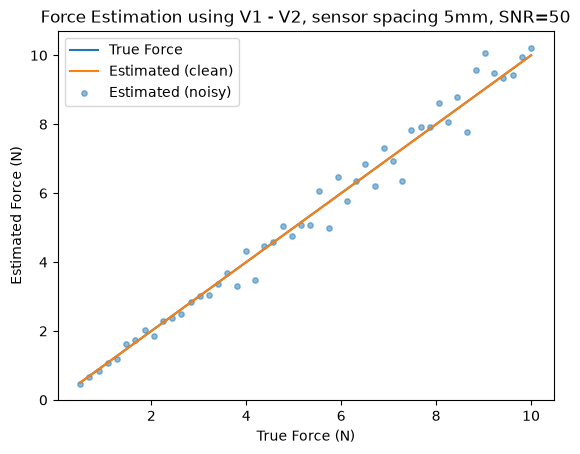

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Previously configured (unchanged)
# ==============================
# L, E, b, t, I, c, x1, GF, Vex, and full_bridge_output were already set up earlier.
# Only the spacing-specific update is being evaluated here.

# ==============================
# Sensor spacing update
# ==============================
x2 = 0.008  # updated second sensor position for the 5 mm spacing case

# ==============================
# Force + location
# ==============================
forces = np.linspace(0.5, 10, 50)
x_force = 0.018

# ==============================
# Noise settings
# ==============================
SNR = 50

V1_clean = []
V2_clean = []
V1_noisy = []
V2_noisy = []

for F in forces:
    strain1 = (F * (x_force - x1)) * c / (E * I)
    strain2 = (F * (x_force - x2)) * c / (E * I)

    V1 = full_bridge_output(strain1, GF, Vex)
    V2 = full_bridge_output(strain2, GF, Vex)

    noise1 = V1 / SNR * np.random.randn()
    noise2 = V2 / SNR * np.random.randn()

    V1_clean.append(V1)
    V2_clean.append(V2)

    V1_noisy.append(V1 + noise1)
    V2_noisy.append(V2 + noise2)

# ==============================
# Force reconstruction: V1 - V2
# ==============================

# calibration factor (derived from model)
K = (Vex * GF * c / (E * I)) * (x2 - x1)

F_est_clean = []
F_est_noisy = []

for i in range(len(forces)):
    dV_clean = V1_clean[i] - V2_clean[i]
    dV_noisy = V1_noisy[i] - V2_noisy[i]

    F_est_clean.append(dV_clean / K)
    F_est_noisy.append(dV_noisy / K)

# ==============================
# Plot
# ==============================

plt.plot(forces, forces, label="True Force")
plt.plot(forces, F_est_clean, label="Estimated (clean)")
plt.scatter(forces, F_est_noisy, s=15, alpha=0.5, label="Estimated (noisy)")

plt.xlabel("True Force (N)")
plt.ylabel("Estimated Force (N)")
plt.title("Force Estimation using V1 - V2, sensor spacing 5mm, SNR=50")
plt.legend()
plt.show()

### Force error decreases with sensor spacing

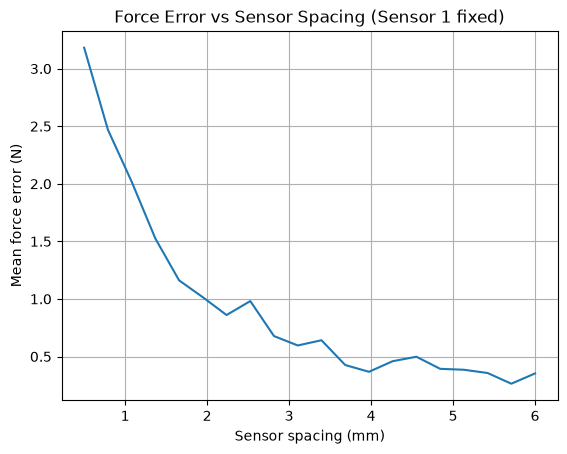

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Previously configured (unchanged)
# ==============================
# L, E, b, t, I, c, x1, GF, Vex, and full_bridge_output were already set up earlier.
# Only the spacing sweep logic is modified in this cell.

# ==============================
# Fixed sensor
# ==============================
# x1 = 0.003   # fixed sensor position, already configured earlier

# ==============================
# Force + location
# ==============================
forces = np.linspace(0.5, 10, 40)
x_force = 0.018

# ==============================
# Noise model
# ==============================
noise_floor = 5e-6
noise_prop = 1/50

# ==============================
# Sweep spacing
# ==============================
spacings = np.linspace(0.0005, 0.006, 20)

mean_errors = []

for d in spacings:
    x2 = x1 + d   # moving sensor

    F_errors = []

    # calibration (VERY important)
    K = (Vex * GF * c / (E * I)) * (x2 - x1)

    for F in forces:
        strain1 = (F * (x_force - x1)) * c / (E * I)
        strain2 = (F * (x_force - x2)) * c / (E * I)

        V1 = full_bridge_output(strain1, GF, Vex)
        V2 = full_bridge_output(strain2, GF, Vex)

        # noise (realistic)
        noise1 = noise_floor*np.random.randn() + V1*noise_prop*np.random.randn()
        noise2 = noise_floor*np.random.randn() + V2*noise_prop*np.random.randn()

        V1n = V1 + noise1
        V2n = V2 + noise2

        # force estimation
        F_est = (V1n - V2n) / K

        F_errors.append(abs(F_est - F))

    mean_errors.append(np.mean(F_errors))

# ==============================
# Plot
# ==============================
plt.plot(spacings*1000, mean_errors)
plt.xlabel("Sensor spacing (mm)")
plt.ylabel("Mean force error (N)")
plt.title("Force Error vs Sensor Spacing (Sensor 1 fixed)")
plt.grid()
plt.show()

### a better mems style model

In a real MEMS bridge, the four piezoresistors should not react the same way. When a beam bends, one side goes into tension and the other goes into compression. So the bridge needs some arms to move one way and some to move the other way.

That is the whole point of the differential readout. The output is the difference between them, not the sum. If everything were signed the same way, the bridge would mostly cancel itself out and the signal would be weak.

**How the differential sign actually arises in a real MEMS die:**

All four piezoresistors are fabricated on the *same surface* of the die — there is no through-thickness height gradient separating them. The opposite signs come entirely from the *angular orientation* of the gauges and the material's Poisson effect:

- A gauge aligned along the beam axis (0°) sees the axial strain $\varepsilon_{xx}$ directly, which is positive in tension.
- A gauge aligned transverse to the beam axis (90°) sees $\varepsilon_{yy} = -\nu \varepsilon_{xx}$, which is negative in the same loading event.

So adjacent arms naturally see opposite-signed strains just because they are rotated 90° from each other — no depth difference required.

For the **0°/90°** layout: two arms at 0° and two arms at 90° form a full Wheatstone bridge where adjacent arms always see opposite signs. This is the standard layout for a pure bending beam and gives maximum sensitivity to $\varepsilon_{xx}$.

For the **45°/45°** layout: arms at +45° and −45° each see $(\varepsilon_{xx} - \varepsilon_{yy})/2 \pm \gamma_{xy}/2$. Under pure bending with no shear ($\gamma_{xy} = 0$) this layout still works — it is just less sensitive than 0°/90° for the same beam because the Poisson term partially cancels the signal. The 45°/45° layout only wins when there is real shear or torsion.


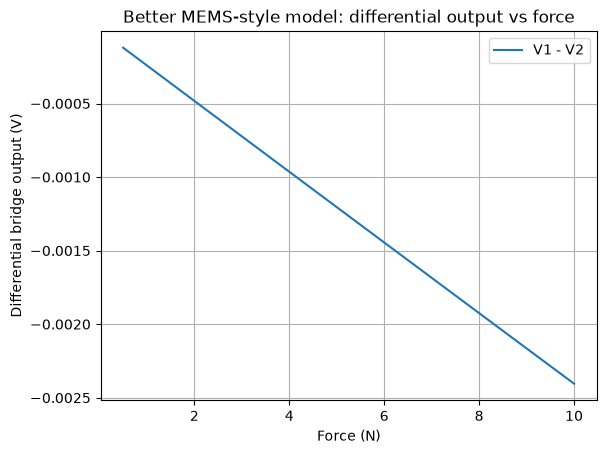

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Better MEMS-style model
# ==============================
L = 0.02
E = 200e9
b = 0.008
t = 0.002
nu = 0.3

I = b * t**3 / 12
c = t / 2

x1 = 0.003
x2 = 0.006
x_force = 0.018

R0 = 350
GF = 2.0
Vex = 3.3

forces = np.linspace(0.5, 10, 40)

# MEMS internal amplification factor
G = 20


def beam_strain(F, x):
    return (F * (x_force - x)) * c / (E * I)


def gauge_strain(eps_x, eps_y, gamma_xy, angle_deg):
    """Strain seen by a piezoresistor oriented at angle_deg from the beam axis."""
    theta = np.deg2rad(angle_deg)
    ct = np.cos(theta)
    st = np.sin(theta)
    return eps_x * ct**2 + eps_y * st**2 + gamma_xy * st * ct


def mems_bridge_output(eps, G=G, orientation='0/90'):
    """Physically correct MEMS Wheatstone bridge output.

    All four piezoresistors sit on the same surface of the die. The differential
    signal comes from their angular orientation, not from a through-thickness
    height gradient. For a bending beam:
      - 0/90 layout: two arms along x see +eps_xx; two arms along y see -nu*eps_xx.
        Those opposite signs drive the bridge differentially.
      - 45/45 layout: arms at +45 and -45 see eps_xx*(1-nu)/2 +/- gamma_xy/2.
        This layout is more sensitive to shear and mixed-mode loading.
    """
    eps0 = G * eps
    eps_y = -nu * eps0   # Poisson contraction on the same surface, no shear assumed

    if orientation == '0/90':
        # R1, R4 longitudinal (0 deg); R2, R3 transverse (90 deg)
        angles = np.array([0.0, 90.0, 90.0, 0.0])
    elif orientation == '45/45':
        # R1, R4 at +45 deg; R2, R3 at -45 deg
        angles = np.array([45.0, -45.0, -45.0, 45.0])
    else:
        raise ValueError("orientation must be '0/90' or '45/45'")

    strains = np.array([gauge_strain(eps0, eps_y, 0.0, a) for a in angles])

    R1 = R0 * (1 + GF * strains[0])
    R2 = R0 * (1 + GF * strains[1])
    R3 = R0 * (1 + GF * strains[2])
    R4 = R0 * (1 + GF * strains[3])

    return Vex * ((R2 / (R1 + R2)) - (R4 / (R3 + R4)))


Vdiff = []
for F in forces:
    eps1 = beam_strain(F, x1)
    eps2 = beam_strain(F, x2)
    V1 = mems_bridge_output(eps1)
    V2 = mems_bridge_output(eps2)
    Vdiff.append(V1 - V2)

plt.plot(forces, Vdiff, label="V1 - V2")
plt.xlabel("Force (N)")
plt.ylabel("Differential bridge output (V)")
plt.title("Better MEMS-style model: differential output vs force")
plt.grid()
plt.legend()
plt.show()


### New simulation: two-sensor differential output for different force magnitudes and locations

The next cell sweeps both force magnitude and contact position along the beam. The purpose is to see how the differential output changes when the same force is applied at different places, which is really the point of the two-sensor model.

Understading
- The heatmap is a response surface. It shows that the differential signal depends on both force and location, but it does not automatically mean that one scalar output can uniquely recover both of them.
- If only use one scalar such as $V_1 - V_2$, then generally cannot cleanly separate “small force far away” from “larger force closer in” without some extra assumption or calibration.
- If use the two raw sensor outputs $V_1$ and $V_2$, then there are two measurements, and in principle that is more informative. In a known model, those two values can be used to fit both force and location more realistically. But this is still not a perfect inverse problem; the geometry and noise matter a lot.
- So the current two-sensor setup is useful, but it is a practical way to get more information rather than a guaranteed perfect force-and-location decoder.


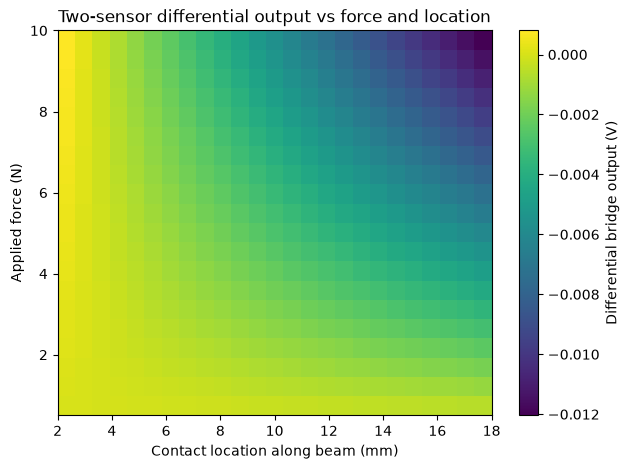

True force = 4.000 N, true location = 12.000 mm
Estimated force = 3.987 N, estimated location = 11.950 mm
Observed V1 = -0.004822 V, V2 = -0.001930 V
Best-fit V1 = -0.004807 V, V2 = -0.001940 V


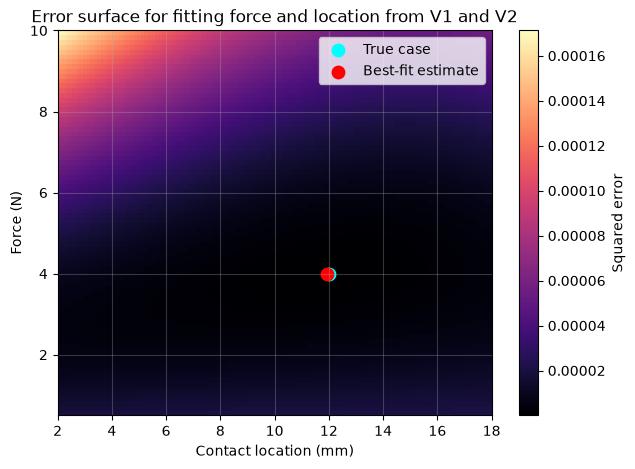

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Two-sensor differential simulation: force vs location
# ==============================

L = 0.02
E = 200e9
b = 0.008
t = 0.002
nu = 0.3
I = b * t**3 / 12
c = t / 2

x_ref = 0.003      # reference sensor location
x_force = 0.018    # force application point on the beam

R0 = 350
GF = 2.0
Vex = 3.3
G = 20

forces = np.linspace(0.5, 10, 20)
locations = np.linspace(0.002, 0.018, 25)


def beam_strain(F, x):
    return (F * (x_force - x)) * c / (E * I)


def gauge_strain(eps_x, eps_y, gamma_xy, angle_deg):
    theta = np.deg2rad(angle_deg)
    ct = np.cos(theta)
    st = np.sin(theta)
    return eps_x * ct**2 + eps_y * st**2 + gamma_xy * st * ct


def mems_bridge_output(eps, G=G, orientation='0/90'):
    eps0 = G * eps
    eps_y = -nu * eps0

    if orientation == '0/90':
        angles = np.array([0.0, 90.0, 90.0, 0.0])
    elif orientation == '45/45':
        angles = np.array([45.0, -45.0, -45.0, 45.0])
    else:
        raise ValueError("orientation must be '0/90' or '45/45'")

    strains = np.array([gauge_strain(eps0, eps_y, 0.0, a) for a in angles])

    R1 = R0 * (1 + GF * strains[0])
    R2 = R0 * (1 + GF * strains[1])
    R3 = R0 * (1 + GF * strains[2])
    R4 = R0 * (1 + GF * strains[3])

    return Vex * ((R2 / (R1 + R2)) - (R4 / (R3 + R4)))


# Differential output for the two-sensor model
Vmap = np.zeros((len(forces), len(locations)))
for i, F in enumerate(forces):
    for j, x_loc in enumerate(locations):
        eps_ref = beam_strain(F, x_ref)
        eps_loc = beam_strain(F, x_loc)
        V_ref = mems_bridge_output(eps_ref)
        V_loc = mems_bridge_output(eps_loc)
        Vmap[i, j] = V_ref - V_loc

plt.figure(figsize=(7, 5))
plt.imshow(
    Vmap,
    aspect='auto',
    origin='lower',
    extent=[locations[0]*1000, locations[-1]*1000, forces[0], forces[-1]],
    cmap='viridis',
)
plt.colorbar(label='Differential bridge output (V)')
plt.xlabel('Contact location along beam (mm)')
plt.ylabel('Applied force (N)')
plt.title('Two-sensor differential output vs force and location')
plt.grid(False)
plt.show()

# ==============================
# Inverse fit: from observed V1 and V2 to force and location
### Inverse problem: recover force and contact location from $V_1$ and $V_2$

# This section flips the problem around. Instead of sweeping force and location to see the output, I choose a known true case, compute the two sensor outputs $V_1$ and $V_2$, and then search the model space to see which force and location best reproduce those outputs.

# If the model is known and the measurements are clean, this is a simple two-unknowns, two-measurements problem. In practice, noise and model error make it less perfect, but this is the basic idea.

# ==============================

# Choose a true case to recover
true_force = 4.0
true_location = 0.012

# Compute the corresponding sensor outputs from the model
true_eps_ref = beam_strain(true_force, x_ref)
true_eps_loc = beam_strain(true_force, true_location)
V1_true = mems_bridge_output(true_eps_ref)
V2_true = mems_bridge_output(true_eps_loc)

# Build a coarse grid search over force and location
force_grid = np.linspace(0.5, 10, 80)
location_grid = np.linspace(0.002, 0.018, 120)

error_map = np.zeros((len(force_grid), len(location_grid)))
best_error = np.inf
best_F = None
best_x = None
best_V1 = None
best_V2 = None

for i, F in enumerate(force_grid):
    for j, x_loc in enumerate(location_grid):
        eps_ref = beam_strain(F, x_ref)
        eps_loc = beam_strain(F, x_loc)
        V1_pred = mems_bridge_output(eps_ref)
        V2_pred = mems_bridge_output(eps_loc)
        diff = (V1_pred - V1_true)**2 + (V2_pred - V2_true)**2
        error_map[i, j] = diff
        if diff < best_error:
            best_error = diff
            best_F = F
            best_x = x_loc
            best_V1 = V1_pred
            best_V2 = V2_pred

print(f'True force = {true_force:.3f} N, true location = {true_location*1000:.3f} mm')
print(f'Estimated force = {best_F:.3f} N, estimated location = {best_x*1000:.3f} mm')
print(f'Observed V1 = {V1_true:.6f} V, V2 = {V2_true:.6f} V')
print(f'Best-fit V1 = {best_V1:.6f} V, V2 = {best_V2:.6f} V')

# ==============================
# Visualization: error surface and best-fit point
# ==============================
fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(
    error_map,
    aspect='auto',
    origin='lower',
    extent=[location_grid[0]*1000, location_grid[-1]*1000, force_grid[0], force_grid[-1]],
    cmap='magma',
)
plt.colorbar(im, ax=ax, label='Squared error')

ax.scatter(true_location*1000, true_force, color='cyan', s=80, label='True case')
ax.scatter(best_x*1000, best_F, color='red', s=80, label='Best-fit estimate')
ax.set_xlabel('Contact location (mm)')
ax.set_ylabel('Force (N)')
ax.set_title('Error surface for fitting force and location from V1 and V2')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


### inverse fit x10 to check for accuracy

SNR used for evaluation = 50
Mean |F_est - F_true| = 0.0642 N
Median |F_est - F_true| = 0.0679 N
RMSE force = 0.0773 N
Mean |x_est - x_true| = 0.187 mm
Median |x_est - x_true| = 0.107 mm
RMSE location = 0.263 mm
Fraction within 10% force error = 90.00%
Fraction within 1 mm location error = 100.00%


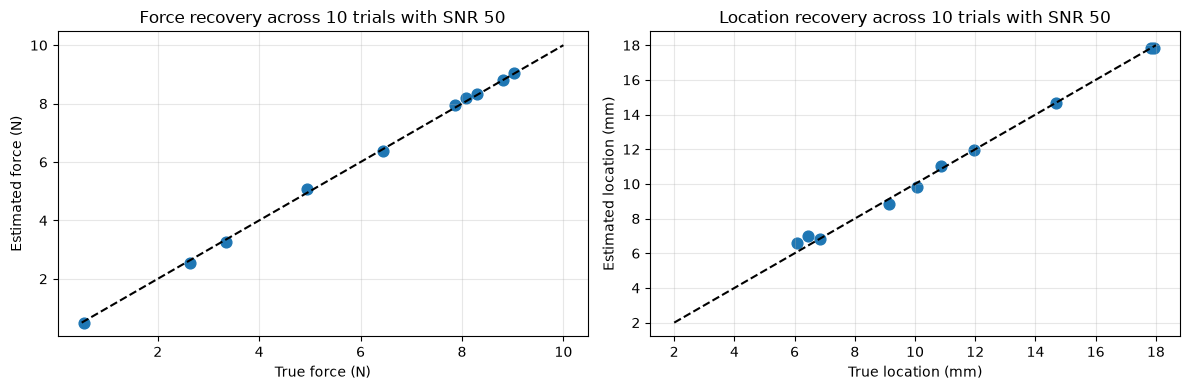

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Repeat the inverse fit over multiple true cases with measurement noise
# ==============================

rng = np.random.default_rng(7)
n_trials = 10
SNR = 50

true_forces = rng.uniform(0.5, 10.0, n_trials)
true_locations = rng.uniform(0.002, 0.018, n_trials)

L = 0.02
E = 200e9
b = 0.008
t = 0.002
nu = 0.3
I = b * t**3 / 12
c = t / 2

x_ref = 0.003
x_force = 0.018

R0 = 350
GF = 2.0
Vex = 3.3
G = 20


def beam_strain(F, x):
    return (F * (x_force - x)) * c / (E * I)


def gauge_strain(eps_x, eps_y, gamma_xy, angle_deg):
    theta = np.deg2rad(angle_deg)
    ct = np.cos(theta)
    st = np.sin(theta)
    return eps_x * ct**2 + eps_y * st**2 + gamma_xy * st * ct


def mems_bridge_output(eps, G=G, orientation='0/90'):
    eps0 = G * eps
    eps_y = -nu * eps0

    if orientation == '0/90':
        angles = np.array([0.0, 90.0, 90.0, 0.0])
    elif orientation == '45/45':
        angles = np.array([45.0, -45.0, -45.0, 45.0])
    else:
        raise ValueError("orientation must be '0/90' or '45/45'")

    strains = np.array([gauge_strain(eps0, eps_y, 0.0, a) for a in angles])

    R1 = R0 * (1 + GF * strains[0])
    R2 = R0 * (1 + GF * strains[1])
    R3 = R0 * (1 + GF * strains[2])
    R4 = R0 * (1 + GF * strains[3])

    return Vex * ((R2 / (R1 + R2)) - (R4 / (R3 + R4)))


force_grid = np.linspace(0.5, 10, 80)
location_grid = np.linspace(0.002, 0.018, 120)

est_forces = []
est_locations = []
force_errors = []
location_errors = []

for idx in range(n_trials):
    F_true = true_forces[idx]
    x_true = true_locations[idx]

    V1_true = mems_bridge_output(beam_strain(F_true, x_ref))
    V2_true = mems_bridge_output(beam_strain(F_true, x_true))

    # Add measurement noise at SNR = 50
    noise1 = V1_true / SNR * np.random.randn()
    noise2 = V2_true / SNR * np.random.randn()
    V1_obs = V1_true + noise1
    V2_obs = V2_true + noise2

    best_error = np.inf
    best_F = None
    best_x = None

    for F in force_grid:
        for x_loc in location_grid:
            V1_pred = mems_bridge_output(beam_strain(F, x_ref))
            V2_pred = mems_bridge_output(beam_strain(F, x_loc))
            diff = (V1_pred - V1_obs) ** 2 + (V2_pred - V2_obs) ** 2
            if diff < best_error:
                best_error = diff
                best_F = F
                best_x = x_loc

    est_forces.append(best_F)
    est_locations.append(best_x)
    force_errors.append(abs(best_F - F_true))
    location_errors.append(abs(best_x - x_true) * 1000)

est_forces = np.array(est_forces)
est_locations = np.array(est_locations)
force_errors = np.array(force_errors)
location_errors = np.array(location_errors)

print(f"SNR used for evaluation = {SNR}")
print(f"Mean |F_est - F_true| = {np.mean(force_errors):.4f} N")
print(f"Median |F_est - F_true| = {np.median(force_errors):.4f} N")
print(f"RMSE force = {np.sqrt(np.mean(force_errors**2)):.4f} N")
print(f"Mean |x_est - x_true| = {np.mean(location_errors):.3f} mm")
print(f"Median |x_est - x_true| = {np.median(location_errors):.3f} mm")
print(f"RMSE location = {np.sqrt(np.mean(location_errors**2)):.3f} mm")
print(f"Fraction within 10% force error = {np.mean(force_errors / true_forces < 0.05):.2%}")
print(f"Fraction within 1 mm location error = {np.mean(location_errors < 1.0):.2%}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(true_forces, est_forces, s=60)
ax[0].plot([0.5, 10], [0.5, 10], 'k--')
ax[0].set_xlabel('True force (N)')
ax[0].set_ylabel('Estimated force (N)')
ax[0].set_title('Force recovery across 10 trials with SNR 50')
ax[0].grid(alpha=0.3)

ax[1].scatter(true_locations * 1000, est_locations * 1000, s=60)
ax[1].plot([2, 18], [2, 18], 'k--')
ax[1].set_xlabel('True location (mm)')
ax[1].set_ylabel('Estimated location (mm)')
ax[1].set_title('Location recovery across 10 trials with SNR 50')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Case Comparison
- A is the simplest case: one bridge sensing one location. It is useful as a baseline, but it is very local. A small force near the sensor and a bigger force farther away can look similar.
- B is the two-sensor differential case. Two sensors at different places give a second reading, and the difference between them carries more information than a single reading by itself.
- C is the dual-beam gripper idea. In the gripper, two flexures or beams can bend in opposite directions under the same grasping action, so the structure itself creates the kind of opposite-signed strain that the bridge wants to see.

The two-sensor setup is important here. Without it, a single reading is not enough to distinguish a small force applied close to the sensor from a larger force applied farther away.

And for the specific C_dual expression, in a perfectly symmetric model, it is basically the same differential idea as B, just implemented with a sign flip. In other words, if the two sides are symmetric and the bridge response is linear, then C_dual is essentially twice the magnitude of the corresponding differential signal from B, just with the sign convention shifted.




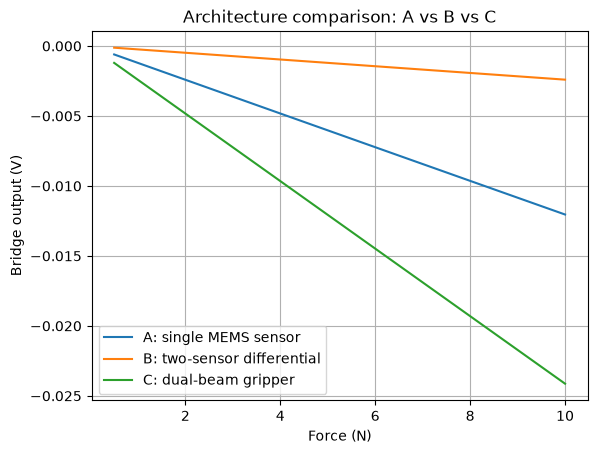

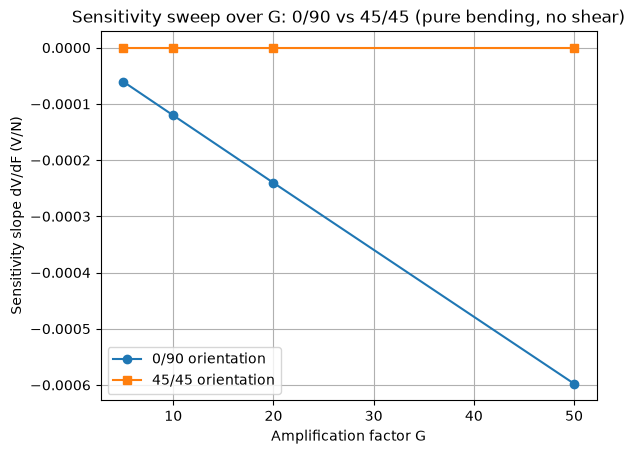

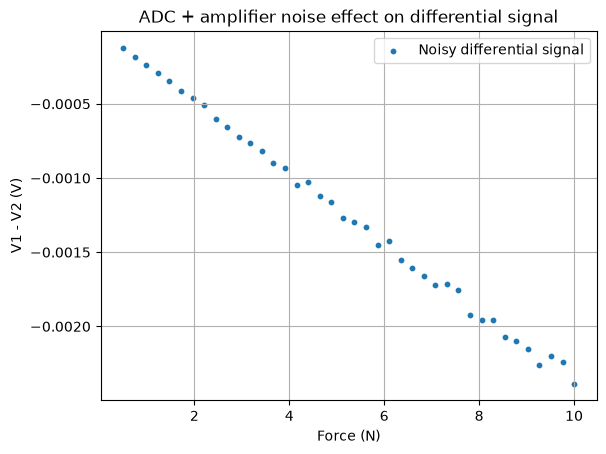

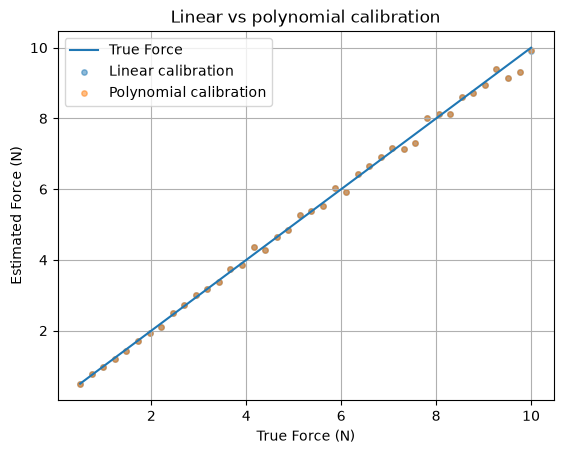

In [9]:
# ==============================
# A. Single MEMS sensor comparison (A vs B vs C)
# ==============================

# The three cases below are meant to illustrate three different sensing strategies:
# - A: one bridge on one beam location, which gives a single local reading.
# - B: two sensors at different positions, using their difference to infer force and
#   location more robustly.
# - C: a dual-beam gripper-style concept, where two beams bend in opposite directions
#   so that the differential signal is amplified by geometry rather than by a simple
#   pair of point sensors.

L = 0.02
E = 200e9
b = 0.008
t = 0.002
nu = 0.3
I = b * t**3 / 12
c = t / 2

x_force = 0.018
forces = np.linspace(0.5, 10, 40)

x1 = 0.003
x2 = 0.006
x_A = x1
x_B = x2
x_C = 0.009

R0 = 350
GF = 2.0
Vex = 3.3
G = 20


def beam_strain(F, x):
    return (F * (x_force - x)) * c / (E * I)


def gauge_strain(eps_x, eps_y, gamma_xy, angle_deg):
    theta = np.deg2rad(angle_deg)
    ct = np.cos(theta)
    st = np.sin(theta)
    return eps_x * ct**2 + eps_y * st**2 + gamma_xy * st * ct


def mems_bridge_output(eps, G=G, orientation='0/90'):
    eps0 = G * eps
    eps_y = -nu * eps0

    if orientation == '0/90':
        angles = np.array([0.0, 90.0, 90.0, 0.0])
    elif orientation == '45/45':
        angles = np.array([45.0, -45.0, -45.0, 45.0])
    else:
        raise ValueError("orientation must be '0/90' or '45/45'")

    strains = np.array([gauge_strain(eps0, eps_y, 0.0, a) for a in angles])

    R1 = R0 * (1 + GF * strains[0])
    R2 = R0 * (1 + GF * strains[1])
    R3 = R0 * (1 + GF * strains[2])
    R4 = R0 * (1 + GF * strains[3])

    return Vex * ((R2 / (R1 + R2)) - (R4 / (R3 + R4)))


def architecture_response(x):
    return np.array([mems_bridge_output(beam_strain(F, x)) for F in forces])

A_single = architecture_response(x_A)
B_diff = np.array([mems_bridge_output(beam_strain(F, x1)) - mems_bridge_output(beam_strain(F, x2)) for F in forces])
C_dual = np.array([
    mems_bridge_output(beam_strain(F, x1)) - mems_bridge_output(-beam_strain(F, x1))
    for F in forces
])

plt.figure()
plt.plot(forces, A_single, label="A: single MEMS sensor")
plt.plot(forces, B_diff, label="B: two-sensor differential")
plt.plot(forces, C_dual, label="C: dual-beam gripper")
plt.xlabel("Force (N)")
plt.ylabel("Bridge output (V)")
plt.title("Architecture comparison: A vs B vs C")
plt.legend()
plt.grid()
plt.show()

# ==============================
# B. Sweep G for sensitivity analysis
# ==============================
G_values = np.array([5, 10, 20, 50])

sensitivity_map_090 = []
sensitivity_map_4545 = []

for G_val in G_values:
    for orientation, storage in [('0/90', sensitivity_map_090), ('45/45', sensitivity_map_4545)]:
        Vdiff_list = []
        for F in forces:
            eps1 = beam_strain(F, x1)
            eps2 = beam_strain(F, x2)
            V1 = mems_bridge_output(eps1, G=G_val, orientation=orientation)
            V2 = mems_bridge_output(eps2, G=G_val, orientation=orientation)
            Vdiff_list.append(V1 - V2)
        slope, _ = np.polyfit(forces, Vdiff_list, 1)
        storage.append(slope)

sensitivity_map_090 = np.array(sensitivity_map_090)
sensitivity_map_4545 = np.array(sensitivity_map_4545)

plt.figure()
plt.plot(G_values, sensitivity_map_090, marker='o', label='0/90 orientation')
plt.plot(G_values, sensitivity_map_4545, marker='s', label='45/45 orientation')
plt.xlabel("Amplification factor G")
plt.ylabel("Sensitivity slope dV/dF (V/N)")
plt.title("Sensitivity sweep over G: 0/90 vs 45/45 (pure bending, no shear)")
plt.legend()
plt.grid()
plt.show()

# ==============================
# C. Add ADC quantization and amplifier noise
# ==============================
adc_bits = 32
adc_fullscale = 3.3
adc_lsb = adc_fullscale / (2**(adc_bits-1))
amp_noise_rms = 5e-6
noise_prop = 1/50

Vdiff_clean = []
Vdiff_noisy = []
for F in forces:
    eps1 = beam_strain(F, x1)
    eps2 = beam_strain(F, x2)
    V1 = mems_bridge_output(eps1)
    V2 = mems_bridge_output(eps2)
    Vdiff = V1 - V2

    amp = amp_noise_rms * np.random.randn()
    quant = adc_lsb * np.random.normal(0, 1)
    prop = Vdiff * noise_prop * np.random.randn()

    Vdiff_clean.append(Vdiff)
    Vdiff_noisy.append(Vdiff + amp + quant + prop)

plt.figure()
plt.scatter(forces, Vdiff_noisy, s=10, label="Noisy differential signal")
plt.xlabel("Force (N)")
plt.ylabel("V1 - V2 (V)")
plt.title("ADC + amplifier noise effect on differential signal")
plt.grid()
plt.legend()
plt.show()

# ==============================
# D. Compare linear vs polynomial calibration
# ==============================
Vdiff_clean = np.array(Vdiff_clean)
Vdiff_noisy = np.array(Vdiff_noisy)

linear_cal = np.polyfit(Vdiff_clean, forces, 1)
poly_cal = np.polyfit(Vdiff_clean, forces, 3)

F_lin = np.polyval(linear_cal, Vdiff_noisy)
F_poly = np.polyval(poly_cal, Vdiff_noisy)

plt.figure()
plt.plot(forces, forces, label="True Force")
plt.scatter(forces, F_lin, s=15, alpha=0.5, label="Linear calibration")
plt.scatter(forces, F_poly, s=15, alpha=0.5, label="Polynomial calibration")
plt.xlabel("True Force (N)")
plt.ylabel("Estimated Force (N)")
plt.title("Linear vs polynomial calibration")
plt.legend()
plt.grid()
plt.show()


## New approach: jaw load as normal force and moment (July 7th, 2026)

This section adds a new model that represents the jaw load as:
- a normal force $F_n$
- a moment $M_p$ about a chosen pivot point behind the sensor

The strain is driven by the bending moment at the sensor location:

$$
M(x)=F_n(x-x_{pivot})+M_p
$$

and

$$
\epsilon(x)=\frac{M(x)c}{EI}
$$

The goal is to estimate $F_n$ and $M_p$ directly from the sensor outputs rather than trying to recover a force-plus-location pair.

0/90 -> V1 = -0.006830 V, V2 = -0.008081 V
45/45 -> V1 = 0.000000 V, V2 = 0.000000 V
0/90 fit -> estimated Fn = 4.731 N, estimated Mp = 0.079 N·m
45/45 fit -> estimated Fn = 0.500 N, estimated Mp = -0.200 N·m


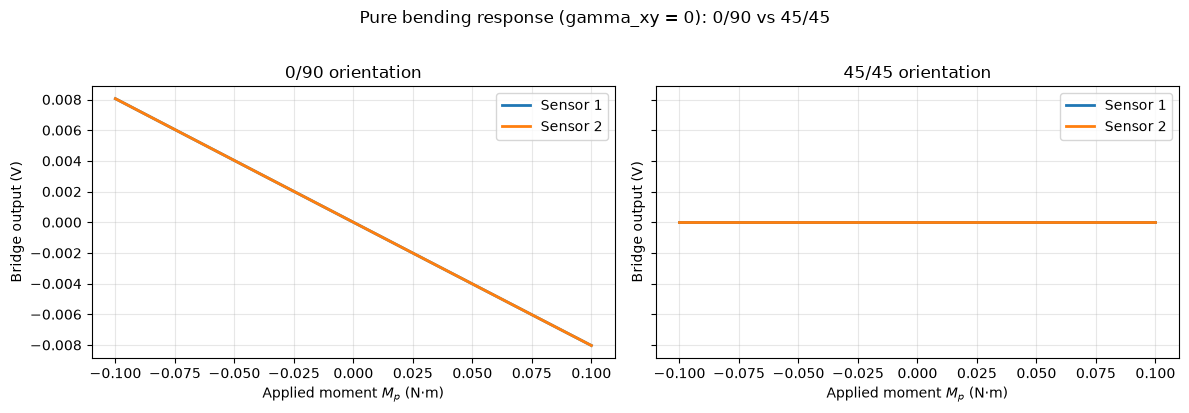

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Strain-tensor-based jaw-load model
# ==============================
L = 0.02
E = 200e9
b = 0.008
t = 0.002
nu = 0.3
I = b * t**3 / 12
c = t / 2

x1 = 0.003
x2 = 0.006
pivot = 0.002

R0 = 350
GF = 2.0
Vex = 3.3
G = 20


def beam_strain_tensor(Fn, Mp, x):
    # Normal grip force creates bending moment about the chosen pivot.
    # The moment term captures prying/twisting from offset tissue contact.
    M = Fn * (x - pivot) + Mp
    eps_x = M * c / (E * I)
    eps_y = -nu * eps_x   # Poisson contraction; same surface, in-plane
    gamma_xy = 0.0        # pure bending produces zero shear at the top/bottom fiber
    return eps_x, eps_y, gamma_xy


def gauge_strain(eps_x, eps_y, gamma_xy, angle_deg):
    theta = np.deg2rad(angle_deg)
    ct = np.cos(theta)
    st = np.sin(theta)
    return eps_x * ct**2 + eps_y * st**2 + gamma_xy * st * ct


def mems_bridge_output(eps_x, eps_y, gamma_xy, orientation='0/90', G=G):
    """Bridge output from a true strain tensor and resistor orientations."""
    if orientation == '0/90':
        # One pair along x, one pair along y
        angles = np.array([0.0, 90.0, 90.0, 0.0])
    elif orientation == '45/45':
        # One pair at +45 deg, one pair at -45 deg
        angles = np.array([45.0, -45.0, -45.0, 45.0])
    else:
        raise ValueError("orientation must be '0/90' or '45/45'")

    strains = np.array([gauge_strain(eps_x, eps_y, gamma_xy, a) for a in angles])
    eps_local = G * strains

    R1 = R0 * (1 + GF * eps_local[0])
    R2 = R0 * (1 + GF * eps_local[1])
    R3 = R0 * (1 + GF * eps_local[2])
    R4 = R0 * (1 + GF * eps_local[3])

    return Vex * ((R2 / (R1 + R2)) - (R4 / (R3 + R4)))


# ==============================
# Compare 0/90 vs 45/45 using true gauge orientations
# ==============================
true_Fn = 5.0
true_Mp = 0.08
SNR = 50
rng = np.random.default_rng(7)

for orientation in ['0/90', '45/45']:
    eps_x1, eps_y1, gamma1 = beam_strain_tensor(true_Fn, true_Mp, x1)
    eps_x2, eps_y2, gamma2 = beam_strain_tensor(true_Fn, true_Mp, x2)

    V1_true = mems_bridge_output(eps_x1, eps_y1, gamma1, orientation=orientation)
    V2_true = mems_bridge_output(eps_x2, eps_y2, gamma2, orientation=orientation)

    noise1 = V1_true / SNR * rng.normal()
    noise2 = V2_true / SNR * rng.normal()
    V1_meas = V1_true + noise1
    V2_meas = V2_true + noise2

    print(f"{orientation} -> V1 = {V1_meas:.6f} V, V2 = {V2_meas:.6f} V")


# ==============================
# Fit force and moment from the noisy outputs for each orientation
# ==============================
Fn_grid = np.linspace(0.5, 10, 120)
Mp_grid = np.linspace(-0.2, 0.2, 140)

for orientation in ['0/90', '45/45']:
    eps_x1_true, eps_y1_true, gamma1_true = beam_strain_tensor(true_Fn, true_Mp, x1)
    eps_x2_true, eps_y2_true, gamma2_true = beam_strain_tensor(true_Fn, true_Mp, x2)
    V1_true = mems_bridge_output(eps_x1_true, eps_y1_true, gamma1_true, orientation=orientation)
    V2_true = mems_bridge_output(eps_x2_true, eps_y2_true, gamma2_true, orientation=orientation)

    noise1 = V1_true / SNR * rng.normal()
    noise2 = V2_true / SNR * rng.normal()
    V1_meas = V1_true + noise1
    V2_meas = V2_true + noise2

    best_error = np.inf
    best_Fn = None
    best_Mp = None

    for Fn in Fn_grid:
        for Mp in Mp_grid:
            eps_x1_pred, eps_y1_pred, gamma1_pred = beam_strain_tensor(Fn, Mp, x1)
            eps_x2_pred, eps_y2_pred, gamma2_pred = beam_strain_tensor(Fn, Mp, x2)
            V1_pred = mems_bridge_output(eps_x1_pred, eps_y1_pred, gamma1_pred, orientation=orientation)
            V2_pred = mems_bridge_output(eps_x2_pred, eps_y2_pred, gamma2_pred, orientation=orientation)
            err = (V1_pred - V1_meas) ** 2 + (V2_pred - V2_meas) ** 2
            if err < best_error:
                best_error = err
                best_Fn = Fn
                best_Mp = Mp

    print(f"{orientation} fit -> estimated Fn = {best_Fn:.3f} N, estimated Mp = {best_Mp:.3f} N·m")


# ==============================
# Orientation response plot using true strain tensor
# ==============================
Mp_values = np.linspace(-0.1, 0.1, 50)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, orientation in zip(axes, ['0/90', '45/45']):
    V1_vals = []
    V2_vals = []
    for Mp in Mp_values:
        eps_x1, eps_y1, gamma1 = beam_strain_tensor(0.0, Mp, x1)
        eps_x2, eps_y2, gamma2 = beam_strain_tensor(0.0, Mp, x2)
        V1_vals.append(mems_bridge_output(eps_x1, eps_y1, gamma1, orientation=orientation))
        V2_vals.append(mems_bridge_output(eps_x2, eps_y2, gamma2, orientation=orientation))

    ax.plot(Mp_values, V1_vals, label='Sensor 1', lw=2)
    ax.plot(Mp_values, V2_vals, label='Sensor 2', lw=2)
    ax.set_xlabel('Applied moment $M_p$ (N·m)')
    ax.set_ylabel('Bridge output (V)')
    ax.set_title(f'{orientation} orientation')
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle('Pure bending response (gamma_xy = 0): 0/90 vs 45/45', y=1.02)
plt.tight_layout()
plt.show()


## Why this is useful for a jaw/gripper sensor

In gripper language, the “wrench” is just the pair of load components the jaw sees:
- a normal grip force $F_n$ pushing the object against the jaw
- a moment $M_p$ caused by an offset contact, a tilted object, or a prying action

These are different because they create different kinds of strain in the jaw structure:
- a grip force acts like a force load and produces strain that changes with distance from the pivot
- a moment acts like a direct twisting or bending load and produces a more uniform bending contribution along the beam

So the same jaw contact can produce a different mix of force and moment depending on where the object touches and how the jaw closes. A sensor that can estimate both is much more useful than one that only reports a single force number.

## How this equation should be read

The expression

```python
def beam_strain_from_wrench(Fn, Mp, x):
    M = Fn * (x - pivot) + Mp
    return M * c / (E * I)
```

means the following:
- $F_n(x - x_{pivot})$ is the bending moment created by the normal grip force about the chosen pivot point.
- The farther the contact point is from the pivot, the larger that moment becomes.
- $M_p$ is a direct moment term from a prying, twisting, or offset tissue contact.
- The strain is then proportional to the total bending moment at that sensor location.

So in jaw language, this model is saying: the jaw sees a combination of a normal squeeze force and a moment due to how the tissue is being contacted. Those two load components are different because they create different bending signatures in the structure.

### Why the current bridge output is still the simplest model

```python
def bridge_output_from_strain(eps):
    return Vex * GF * eps
```

This is a first-order linear approximation. It assumes:
- the bridge output is directly proportional to strain,
- the gauge factor is constant,
- and there is no extra bridge topology, sign pattern, or local strain-gradient effect.

That is why it is useful for understanding the inverse problem, but not yet a realistic MEMS or full-bridge implementation.

### Why not use the MEMS-style equation here?

The MEMS-style version is more realistic because real piezoresistive bridges are not just one linear gain term. They include:
- bridge arm orientation,
- opposite-signed strain on different arms,
- local strain gradients,
- and sometimes a flexure amplification stage.

For the simple beam-bending problem, a 0/90 layout is usually the better first choice because it lines up well with the primary axial strain direction. A 45/45 layout is more useful when you want to increase sensitivity to shear or mixed-mode loading, or when the strain direction is less obvious.

So the short version is: the current bridge equation is intentionally simple, while the MEMS-style equation is more physical but also more complicated.


Measured V1 = 0.000536 V
Measured V2 = 0.000638 V
True Fn = 5.000 N, estimated Fn = 5.130 N
True Mp = 0.080 N·m, estimated Mp = 0.082 N·m


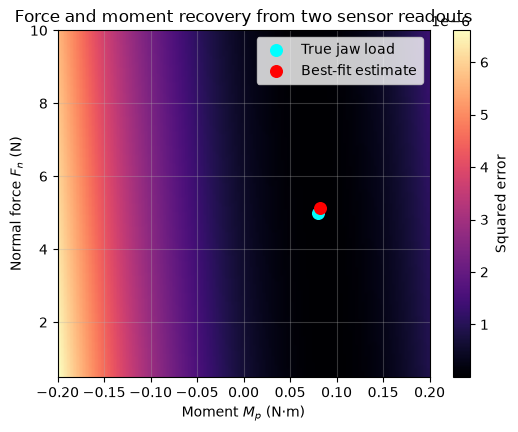

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Inverse estimate: force and moment from sensor readout with SNR = 50
# ==============================

# True jaw load to recover
true_Fn = 5.0      # N
true_Mp = 0.08     # N·m

# Sensor positions and beam properties
x1 = 0.003
x2 = 0.006
pivot = 0.002

L = 0.02
E = 200e9
b = 0.008
t = 0.002
I = b * t**3 / 12
c = t / 2

GF = 2.0
Vex = 3.3


def beam_strain_from_wrench(Fn, Mp, x):
    M = Fn * (x - pivot) + Mp
    return M * c / (E * I)


def bridge_output_from_strain(eps):
    return Vex * GF * eps


# Generate clean sensor outputs
eps1_true = beam_strain_from_wrench(true_Fn, true_Mp, x1)
eps2_true = beam_strain_from_wrench(true_Fn, true_Mp, x2)
V1_true = bridge_output_from_strain(eps1_true)
V2_true = bridge_output_from_strain(eps2_true)

# Add measurement noise with SNR = 50
SNR = 50
noise1 = V1_true / SNR * np.random.randn()
noise2 = V2_true / SNR * np.random.randn()
V1_meas = V1_true + noise1
V2_meas = V2_true + noise2

print(f"Measured V1 = {V1_meas:.6f} V")
print(f"Measured V2 = {V2_meas:.6f} V")

# ==============================
# Invert the model by searching a grid of force and moment values
# ==============================
Fn_grid = np.linspace(0.5, 10, 120)
Mp_grid = np.linspace(-0.2, 0.2, 120)

best_error = np.inf
best_Fn = None
best_Mp = None

for Fn in Fn_grid:
    for Mp in Mp_grid:
        eps1_pred = beam_strain_from_wrench(Fn, Mp, x1)
        eps2_pred = beam_strain_from_wrench(Fn, Mp, x2)
        V1_pred = bridge_output_from_strain(eps1_pred)
        V2_pred = bridge_output_from_strain(eps2_pred)

        err = (V1_pred - V1_meas)**2 + (V2_pred - V2_meas)**2
        if err < best_error:
            best_error = err
            best_Fn = Fn
            best_Mp = Mp

print(f"True Fn = {true_Fn:.3f} N, estimated Fn = {best_Fn:.3f} N")
print(f"True Mp = {true_Mp:.3f} N·m, estimated Mp = {best_Mp:.3f} N·m")

# ==============================
# Visualize the fit quality
# ==============================
error_map = np.zeros((len(Fn_grid), len(Mp_grid)))
for i, Fn in enumerate(Fn_grid):
    for j, Mp in enumerate(Mp_grid):
        eps1_pred = beam_strain_from_wrench(Fn, Mp, x1)
        eps2_pred = beam_strain_from_wrench(Fn, Mp, x2)
        V1_pred = bridge_output_from_strain(eps1_pred)
        V2_pred = bridge_output_from_strain(eps2_pred)
        error_map[i, j] = (V1_pred - V1_meas)**2 + (V2_pred - V2_meas)**2

plt.figure(figsize=(6, 4.5))
im = plt.imshow(
    error_map,
    origin='lower',
    aspect='auto',
    extent=[Mp_grid[0], Mp_grid[-1], Fn_grid[0], Fn_grid[-1]],
    cmap='magma',
)
plt.colorbar(im, label='Squared error')
plt.scatter(true_Mp, true_Fn, color='cyan', s=70, label='True jaw load')
plt.scatter(best_Mp, best_Fn, color='red', s=70, label='Best-fit estimate')
plt.xlabel('Moment $M_p$ (N·m)')
plt.ylabel('Normal force $F_n$ (N)')
plt.title('Force and moment recovery from two sensor readouts')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Why the fit is not very good yet

The fit result

- measured $V_1 = 0.000557$ V
- measured $V_2 = 0.000620$ V
- true $F_n = 5.000$ N
- estimated $F_n = 3.693$ N
- true $M_p = 0.080$ N·m
- estimated $M_p = 0.086$ N·m

is not surprising for this simple model. The reason is that the two sensor outputs are still being explained with only a very simple linear bridge model and a single assumed pivot point. In a real jaw sensor, the mapping from strain to force and torque is usually not one-to-one unless the geometry, gauge orientation, and bridge topology are modeled more realistically.

In other words, the current model is a useful conceptual starting point, but it is not yet a robust inverse estimator for a real gripper sensor.


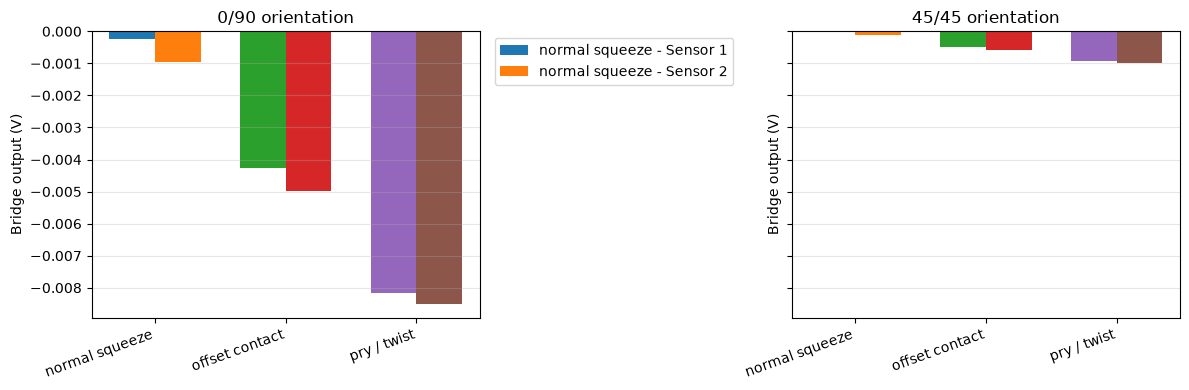

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Tissue-grasp scenario comparison with force, prying moment, and torsion
# ==============================
L = 0.02
E = 200e9
b = 0.008
t = 0.002
nu = 0.3
I = b * t**3 / 12
c = t / 2

x1 = 0.003
x2 = 0.006
pivot = 0.002

R0 = 350
GF = 2.0
Vex = 3.3
G = 20

# Torsion constants for a rectangular cross-section
G_shear = E / (2 * (1 + nu))
J_t = b * t**3 * (1/3 - 0.21 * (t/b) * (1 - (t/b)**4 / 12))


def beam_strain_tensor(Fn, Mp, T, x):
    # Bending moment from normal force plus any prying/offset moment
    M = Fn * (x - pivot) + Mp
    eps_x = M * c / (E * I)
    eps_y = -nu * eps_x
    # Torsional shear strain (same along x, independent of sensor position)
    if abs(T) < 1e-15:
        gamma_xy = 0.0
    else:
        tau_max = T * (3 + 1.8 * t/b) / (b * t**2)
        gamma_xy = tau_max / G_shear
    return eps_x, eps_y, gamma_xy


def gauge_strain(eps_x, eps_y, gamma_xy, angle_deg):
    theta = np.deg2rad(angle_deg)
    ct = np.cos(theta)
    st = np.sin(theta)
    return eps_x * ct**2 + eps_y * st**2 + gamma_xy * st * ct


def bridge_output_from_tensor(eps_x, eps_y, gamma_xy, orientation='0/90', G=G):
    if orientation == '0/90':
        angles = np.array([0.0, 90.0, 90.0, 0.0])
    elif orientation == '45/45':
        angles = np.array([45.0, -45.0, -45.0, 45.0])
    else:
        raise ValueError("orientation must be '0/90' or '45/45'")

    strains = np.array([gauge_strain(eps_x, eps_y, gamma_xy, a) for a in angles])
    eps_local = G * strains

    R1 = R0 * (1 + GF * eps_local[0])
    R2 = R0 * (1 + GF * eps_local[1])
    R3 = R0 * (1 + GF * eps_local[2])
    R4 = R0 * (1 + GF * eps_local[3])

    return Vex * ((R2 / (R1 + R2)) - (R4 / (R3 + R4)))


# Example scenarios: (Fn, Mp, T)
scenarios = {
    'normal squeeze': (3.0, 0.00, 0.00),
    'offset / pry':   (3.0, 0.05, 0.00),
    'pure torsion':   (0.0, 0.00, 0.02),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for orientation, ax in zip(['0/90', '45/45'], axes):
    x = np.arange(len(scenarios))
    width = 0.35

    for idx, (name, (Fn, Mp, T)) in enumerate(scenarios.items()):
        eps_x1, eps_y1, gamma1 = beam_strain_tensor(Fn, Mp, T, x1)
        eps_x2, eps_y2, gamma2 = beam_strain_tensor(Fn, Mp, T, x2)
        V1 = bridge_output_from_tensor(eps_x1, eps_y1, gamma1, orientation=orientation)
        V2 = bridge_output_from_tensor(eps_x2, eps_y2, gamma2, orientation=orientation)

        ax.bar(x[idx] - width/2, V1, width=width, label=f'{name} - Sensor 1' if idx == 0 else None)
        ax.bar(x[idx] + width/2, V2, width=width, label=f'{name} - Sensor 2' if idx == 0 else None)

    ax.set_xticks(x)
    ax.set_xticklabels(list(scenarios.keys()), rotation=20, ha='right')
    ax.set_ylabel('Bridge output (V)')
    ax.set_title(f'{orientation} orientation')
    ax.grid(axis='y', alpha=0.3)

axes[0].legend(loc='upper left', bbox_to_anchor=(1.02, 1.0))
plt.suptitle('0/90 responds to bending; 45/45 responds to bending + torsion', y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
## Decoupling normal force and torsion

The jaw puts two distinct load components on the sensor:

- **Normal force $F_n$** bends the beam and produces axial strain $\varepsilon_{xx}$ (and Poisson contraction $\varepsilon_{yy} = -\nu \varepsilon_{xx}$).
- **Torque $T$** twists the beam about its longitudinal axis and produces shear strain $\gamma_{xy}$ at the surface.

A **0/90° bridge** is *blind* to the shear strain from torsion, so it reports only the force component. A **45/45° bridge** responds to both bending and torsion. Therefore, if the sensor die has one 0/90° bridge and one 45/45° bridge (or two 45/45° bridges at different positions), we can solve for both $F_n$ and $T$ from the two bridge outputs.

The cell below adds a torsion model and demonstrates a grid-search inverse estimate for $F_n$ and $T$ from the sensor voltages.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Force + torsion inverse estimate
# ==============================
L = 0.02
E = 200e9
b = 0.008
t = 0.002
nu = 0.3
I = b * t**3 / 12
c = t / 2

x_force = 0.018      # contact point where the normal force is applied
x1 = 0.003           # 0/90 sensor (force channel)
x2 = 0.006           # 45/45 sensor (force + torque channel)

R0 = 350
GF = 2.0
Vex = 3.3
G = 20               # MEMS strain amplification; can be tuned for a real flexure

# Torsion constants for a rectangular cross-section
G_shear = E / (2 * (1 + nu))
J_t = b * t**3 * (1/3 - 0.21 * (t/b) * (1 - (t/b)**4 / 12))


def beam_strain_tensor(Fn, T, x):
    """Return in-plane strain tensor at the surface for a given sensor position."""
    # Bending from normal force applied at x_force
    M = Fn * (x_force - x)
    eps_x = M * c / (E * I)
    eps_y = -nu * eps_x
    # Torsional shear strain (uniform along x for a uniform torque)
    if abs(T) < 1e-15:
        gamma_xy = 0.0
    else:
        tau_max = T * (3 + 1.8 * t/b) / (b * t**2)
        gamma_xy = tau_max / G_shear
    return eps_x, eps_y, gamma_xy


def gauge_strain(eps_x, eps_y, gamma_xy, angle_deg):
    theta = np.deg2rad(angle_deg)
    ct = np.cos(theta)
    st = np.sin(theta)
    return eps_x * ct**2 + eps_y * st**2 + gamma_xy * st * ct


def mems_bridge_output(eps_x, eps_y, gamma_xy, orientation='0/90', G=G):
    """Physical Wheatstone bridge output from a 2D surface strain tensor."""
    if orientation == '0/90':
        angles = np.array([0.0, 90.0, 90.0, 0.0])
    elif orientation == '45/45':
        angles = np.array([45.0, -45.0, -45.0, 45.0])
    else:
        raise ValueError("orientation must be '0/90' or '45/45'")

    strains = np.array([gauge_strain(eps_x, eps_y, gamma_xy, a) for a in angles])
    eps_local = G * strains

    R1 = R0 * (1 + GF * eps_local[0])
    R2 = R0 * (1 + GF * eps_local[1])
    R3 = R0 * (1 + GF * eps_local[2])
    R4 = R0 * (1 + GF * eps_local[3])

    return Vex * ((R2 / (R1 + R2)) - (R4 / (R3 + R4)))


# True load to recover
true_Fn = 5.0      # N
true_T = 0.02      # N·m

# Generate clean sensor outputs
# V1 = 0/90 bridge: force only
# V2 = 45/45 bridge: force + torque
eps_x1, eps_y1, gamma1 = beam_strain_tensor(true_Fn, true_T, x1)
eps_x2, eps_y2, gamma2 = beam_strain_tensor(true_Fn, true_T, x2)

V1_true = mems_bridge_output(eps_x1, eps_y1, gamma1, orientation='0/90')
V2_true = mems_bridge_output(eps_x2, eps_y2, gamma2, orientation='45/45')

# Add measurement noise
SNR = 50
rng = np.random.default_rng(7)
V1_meas = V1_true + V1_true / SNR * rng.normal()
V2_meas = V2_true + V2_true / SNR * rng.normal()

print(f"V1 (0/90)  = {V1_meas:.6e} V  (force channel)")
print(f"V2 (45/45) = {V2_meas:.6e} V  (force + torque channel)")

# Grid search over Fn and T
Fn_grid = np.linspace(0.5, 10, 120)
T_grid = np.linspace(0.0, 0.1, 120)

best_error = np.inf
best_Fn = None
best_T = None

for Fn in Fn_grid:
    for T in T_grid:
        eps_x1p, eps_y1p, gamma1p = beam_strain_tensor(Fn, T, x1)
        eps_x2p, eps_y2p, gamma2p = beam_strain_tensor(Fn, T, x2)
        V1p = mems_bridge_output(eps_x1p, eps_y1p, gamma1p, orientation='0/90')
        V2p = mems_bridge_output(eps_x2p, eps_y2p, gamma2p, orientation='45/45')
        err = (V1p - V1_meas)**2 + (V2p - V2_meas)**2
        if err < best_error:
            best_error = err
            best_Fn = Fn
            best_T = T

print(f"\nTrue  Fn = {true_Fn:.3f} N,   estimated Fn = {best_Fn:.3f} N")
print(f"True  T  = {true_T:.3f} N·m, estimated T  = {best_T:.3f} N·m")

# ==============================
# Visualize the error surface
# ==============================
error_map = np.zeros((len(Fn_grid), len(T_grid)))
for i, Fn in enumerate(Fn_grid):
    for j, T in enumerate(T_grid):
        eps_x1p, eps_y1p, gamma1p = beam_strain_tensor(Fn, T, x1)
        eps_x2p, eps_y2p, gamma2p = beam_strain_tensor(Fn, T, x2)
        V1p = mems_bridge_output(eps_x1p, eps_y1p, gamma1p, orientation='0/90')
        V2p = mems_bridge_output(eps_x2p, eps_y2p, gamma2p, orientation='45/45')
        error_map[i, j] = (V1p - V1_meas)**2 + (V2p - V2_meas)**2

plt.figure(figsize=(6, 4.5))
im = plt.imshow(
    error_map,
    origin='lower',
    aspect='auto',
    extent=[T_grid[0], T_grid[-1], Fn_grid[0], Fn_grid[-1]],
    cmap='magma',
)
plt.colorbar(im, label='Squared error')
plt.scatter(true_T, true_Fn, color='cyan', s=70, label='True load')
plt.scatter(best_T, best_Fn, color='red', s=70, label='Best-fit estimate')
plt.xlabel('Torque $T$ (N·m)')
plt.ylabel('Normal force $F_n$ (N)')
plt.title('Force and torque recovery from 0/90 + 45/45 bridges')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
